# Compare two VAE latent spaces

This notebook loads two repository checkpoints and compares:

- samples from the standard-normal prior;
- one latent prototype per MNIST class;
- samples from each empirical class-conditional aggregate posterior;
- linear interpolations between class prototypes.

Both models are encoded on the **same raw MNIST split**. Decoder plots use the conditional expected pixel value, so Bernoulli and Continuous-Bernoulli models are compared on the same quantity.

In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from torch.distributions import ContinuousBernoulli
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def find_repo_root(start):
    start = Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from domain_knowledge_analysis import utils
from domain_knowledge_analysis.math.bernoulli import (
    continuous_bernoulli_probs_from_logits,
)

DEVICE = utils.get_device()
print(f"Repository: {REPO_ROOT}")
print(f"Device: {DEVICE}")

/Users/gianmarcoalbano/domain-knowledge-analysis-generative-models/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: /Users/gianmarcoalbano/domain-knowledge-analysis-generative-models
Device: mps


## Settings

Edit the two checkpoint paths below. The defaults point to checkpoints currently present in this repository.

In [ ]:
MODEL_A_CHECKPOINT = (
    REPO_ROOT
    / "runs/vae_mnist_lr_0.001_24_jul_0928/checkpoints/best.pt"
)
MODEL_B_CHECKPOINT = (
    REPO_ROOT
    / "runs/vae_mnist_lr_0.001_24_jul_1148/checkpoints/best.pt"
)

MODEL_A_NAME = "Model B"
MODEL_B_NAME = "Model CB"

DATA_SPLIT = "test"  # "train" or "test"
BATCH_SIZE = 256
NUM_PRIOR_SAMPLES = 12
NUM_CLASS_SAMPLES = 10
INTERPOLATION_STEPS = 12
INTERPOLATION_PAIRS = [(0, 1), (1, 7), (3, 8), (4, 9), (5, 6)]

# "empirical_mixture" samples the encoded class mixture directly.
# "moment_gaussian" uses one moment-matched diagonal Normal per class.
CLASS_SAMPLING_METHOD = "empirical_mixture"
RANDOM_SEED = 42

In [15]:
def load_vae_checkpoint(checkpoint_path, name):
    checkpoint_path = Path(checkpoint_path).expanduser().resolve()
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}\n"
            "Edit MODEL_A_CHECKPOINT and MODEL_B_CHECKPOINT in the settings cell."
        )

    # Only load checkpoints that you trust; torch checkpoints use pickle.
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )
    config = checkpoint["config"]

    model = utils.create_model(config)
    model.load_state_dict(checkpoint["model_state_dict"], strict=True)
    model = model.to(DEVICE).eval()

    return {
        "name": name,
        "path": checkpoint_path,
        "model": model,
        "config": config,
        "checkpoint": checkpoint,
        "latent_dim": config["model"]["encoder"]["latent_dim"],
        "distribution": config.get("loss", {}).get(
            "log_prob_function", "unspecified"
        ),
    }


model_a = load_vae_checkpoint(MODEL_A_CHECKPOINT, MODEL_A_NAME)
model_b = load_vae_checkpoint(MODEL_B_CHECKPOINT, MODEL_B_NAME)
models = [model_a, model_b]

assert model_a["config"]["dataset"]["name"] == model_b["config"]["dataset"]["name"]
assert model_a["config"]["dataset"]["shape"] == model_b["config"]["dataset"]["shape"]

for item in models:
    checkpoint = item["checkpoint"]
    print(
        f"{item['name']}: "
        f"distribution={item['distribution']}, "
        f"latent_dim={item['latent_dim']}, "
        f"epoch={checkpoint.get('epoch', 'unknown')}, "
        f"validation_loss={checkpoint.get('validation_loss', 'unknown')}"
    )
    print(f"  {item['path']}")

FileNotFoundError: Checkpoint not found: /Users/gianmarcoalbano/domain-knowledge-analysis-generative-models/runs/vae_mnist_lr_0.001_23_jul_0824/checkpoints/best.pt
Edit MODEL_A_CHECKPOINT and MODEL_B_CHECKPOINT in the settings cell.

## Shared evaluation data

The repository normally dequantizes inputs only for a Continuous-Bernoulli training configuration. For a controlled latent comparison, this cell deliberately disables that wrapper and gives both encoders the exact same raw `ToTensor()` MNIST images.

In [16]:
evaluation_config = deepcopy(model_a["config"])
evaluation_config.setdefault("loss", {})["log_prob_function"] = "bernoulli"

dataset_name = evaluation_config["dataset"]["name"]
evaluation_dataset = utils.create_dataset(
    config=evaluation_config,
    dataset_name=dataset_name,
    train=(DATA_SPLIT == "train"),
)
evaluation_loader = DataLoader(
    evaluation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(
    f"Using {len(evaluation_dataset)} raw {dataset_name.upper()} "
    f"{DATA_SPLIT} images for both models."
)

Using 10000 raw MNIST test images for both models.


## Encode the dataset and summarize each class

The repository encoder returns `(mean, log_variance)`, not `(mean, std)`. For class `c`, the moment-matched aggregate posterior is computed as

$$\mu_c = \mathbb{E}[\mu(x)], \qquad
\sigma_c^2 = \mathbb{E}[\sigma^2(x) + \mu(x)^2] - \mu_c^2.$$

This includes both posterior uncertainty and variation between encoded examples.

In [17]:
@torch.no_grad()
def encode_dataset(model, data_loader, description):
    model.eval()
    means = []
    log_variances = []
    labels = []

    for images, batch_labels in tqdm(data_loader, desc=description):
        mean, log_variance = model.encoder(images.to(DEVICE))
        means.append(mean.cpu())
        log_variances.append(log_variance.cpu())
        labels.append(batch_labels.cpu())

    mean = torch.cat(means, dim=0)
    log_variance = torch.cat(log_variances, dim=0)
    return {
        "mean": mean,
        "log_variance": log_variance,
        "std": torch.exp(0.5 * log_variance),
        "labels": torch.cat(labels, dim=0),
    }


def get_class_statistics(encoded):
    means = encoded["mean"]
    log_variances = encoded["log_variance"]
    labels = encoded["labels"]
    kl_per_image = 0.5 * (
        log_variances.exp()
        + means.square()
        - 1.0
        - log_variances
    ).sum(dim=1)

    statistics = {}
    for class_id in sorted(labels.unique().tolist()):
        indices = torch.where(labels == class_id)[0]
        class_means = means[indices]
        class_log_variances = log_variances[indices]

        aggregate_mean = class_means.mean(dim=0)
        aggregate_second_moment = (
            class_log_variances.exp() + class_means.square()
        ).mean(dim=0)
        aggregate_variance = (
            aggregate_second_moment - aggregate_mean.square()
        ).clamp_min(1e-8)

        statistics[int(class_id)] = {
            "indices": indices,
            "mean": aggregate_mean,
            "std": aggregate_variance.sqrt(),
            "mean_kl": kl_per_image[indices].mean(),
            "count": len(indices),
        }

    return statistics

In [18]:
for item in models:
    item["encoded"] = encode_dataset(
        item["model"],
        evaluation_loader,
        description=f"Encoding {item['name']}",
    )
    item["class_statistics"] = get_class_statistics(item["encoded"])

assert torch.equal(
    model_a["encoded"]["labels"],
    model_b["encoded"]["labels"],
)

class_ids = sorted(
    set(model_a["class_statistics"])
    & set(model_b["class_statistics"])
)
print(f"Classes: {class_ids}")

Encoding Model CB: 100%|██████████| 40/40 [00:00<00:00, 83.62it/s]


KeyError: 'encoded'

In [ ]:
def print_class_summary(item):
    print(f"\n{item['name']} — {item['distribution']}")
    print("class | count | ||class mean|| | mean aggregate std | mean KL")
    print("------|-------|----------------|--------------------|--------")
    for class_id in class_ids:
        stats = item["class_statistics"][class_id]
        print(
            f"{class_id:>5} | "
            f"{stats['count']:>5} | "
            f"{stats['mean'].norm().item():>14.3f} | "
            f"{stats['std'].mean().item():>18.3f} | "
            f"{stats['mean_kl'].item():>7.3f}"
        )


for item in models:
    print_class_summary(item)


Model B — bernoulli
class | count | ||class mean|| | mean aggregate std | mean KL
------|-------|----------------|--------------------|--------
    0 |   980 |          1.791 |              0.860 |  22.807
    1 |  1135 |          1.887 |              0.911 |  12.360
    2 |  1032 |          1.759 |              0.905 |  27.353
    3 |  1010 |          1.711 |              0.860 |  25.571
    4 |   982 |          1.794 |              0.904 |  24.207
    5 |   892 |          1.764 |              0.877 |  26.365
    6 |   958 |          1.829 |              0.873 |  23.219
    7 |  1028 |          1.800 |              0.893 |  20.797
    8 |   974 |          1.554 |              0.876 |  26.297
    9 |  1009 |          1.484 |              0.832 |  21.424

Model CB — continuous_bernoulli
class | count | ||class mean|| | mean aggregate std | mean KL
------|-------|----------------|--------------------|--------
    0 |   980 |          2.212 |              0.791 |  39.311
    1 |  1135 | 

In [ ]:
@torch.no_grad()
def decode_expected_images(model, latents):
    """Decode E[x|z] so different observation models are comparable."""
    model.eval()
    logits = model.decoder(latents.to(DEVICE))

    if model.decoder_distribution_name == "continuous_bernoulli":
        lambda_ = continuous_bernoulli_probs_from_logits(logits)
        images = ContinuousBernoulli(probs=lambda_).mean
    else:
        images = torch.sigmoid(logits)

    return images.clamp(0.0, 1.0).cpu()


def show_image(axis, image, title=None):
    axis.imshow(image.squeeze().numpy(), cmap="gray", vmin=0.0, vmax=1.0)
    axis.axis("off")
    if title is not None:
        axis.set_title(title)


def sample_class_latents(item, class_id, n_samples, generator, method):
    encoded = item["encoded"]
    stats = item["class_statistics"][class_id]

    if method == "empirical_mixture":
        class_indices = stats["indices"]
        selected = class_indices[
            torch.randint(
                low=0,
                high=len(class_indices),
                size=(n_samples,),
                generator=generator,
            )
        ]
        noise = torch.randn(
            n_samples,
            item["latent_dim"],
            generator=generator,
        )
        return (
            encoded["mean"][selected]
            + encoded["std"][selected] * noise
        )

    if method == "moment_gaussian":
        noise = torch.randn(
            n_samples,
            item["latent_dim"],
            generator=generator,
        )
        return stats["mean"] + stats["std"] * noise

    raise ValueError(
        "CLASS_SAMPLING_METHOD must be 'empirical_mixture' "
        "or 'moment_gaussian'."
    )

## Samples from the prior

These rows decode $z \sim \mathcal{N}(0, I)$. They provide the most direct visual comparison of prior-sampling quality.

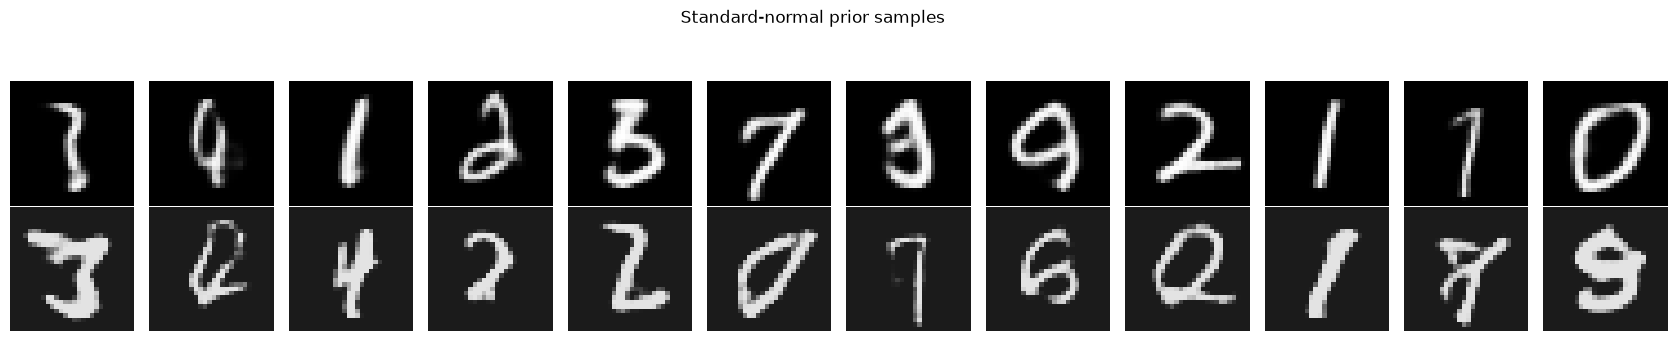

In [ ]:
figure, axes = plt.subplots(
    nrows=2,
    ncols=NUM_PRIOR_SAMPLES,
    figsize=(1.45 * NUM_PRIOR_SAMPLES, 3.5),
    squeeze=False,
)

for row, item in enumerate(models):
    generator = torch.Generator().manual_seed(RANDOM_SEED)
    latents = torch.randn(
        NUM_PRIOR_SAMPLES,
        item["latent_dim"],
        generator=generator,
    )
    images = decode_expected_images(item["model"], latents)

    for column, image in enumerate(images):
        show_image(axes[row, column], image)
    axes[row, 0].set_ylabel(item["name"], rotation=0, labelpad=45, va="center")

figure.suptitle("Standard-normal prior samples")
plt.tight_layout(rect=(0.03, 0.0, 1.0, 0.93))
plt.show()
plt.close(figure)

## Class prototypes

Each image is decoded from the mean of the encoded class aggregate. Separate models have separate latent coordinate systems, so every model uses its own class mean.

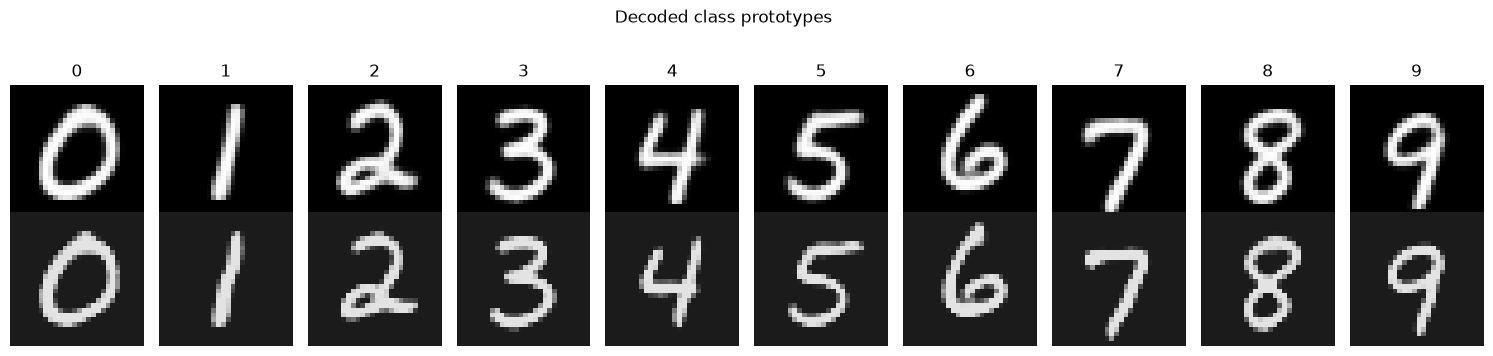

In [ ]:
figure, axes = plt.subplots(
    nrows=2,
    ncols=len(class_ids),
    figsize=(1.55 * len(class_ids), 3.6),
    squeeze=False,
)

for row, item in enumerate(models):
    prototype_latents = torch.stack(
        [item["class_statistics"][class_id]["mean"] for class_id in class_ids]
    )
    prototype_images = decode_expected_images(item["model"], prototype_latents)

    for column, (class_id, image) in enumerate(zip(class_ids, prototype_images)):
        show_image(axes[row, column], image, title=str(class_id) if row == 0 else None)
    axes[row, 0].set_ylabel(item["name"], rotation=0, labelpad=45, va="center")

figure.suptitle("Decoded class prototypes")
plt.tight_layout(rect=(0.03, 0.0, 1.0, 0.93))
plt.show()
plt.close(figure)

## Class-conditioned latent samples

With the default `empirical_mixture` method, an encoded example of the requested class is chosen uniformly and then one latent is sampled from its posterior. This samples the empirical approximation to $q(z\mid y=c)$ directly. Change the setting to `moment_gaussian` to use one moment-matched diagonal Normal per class.

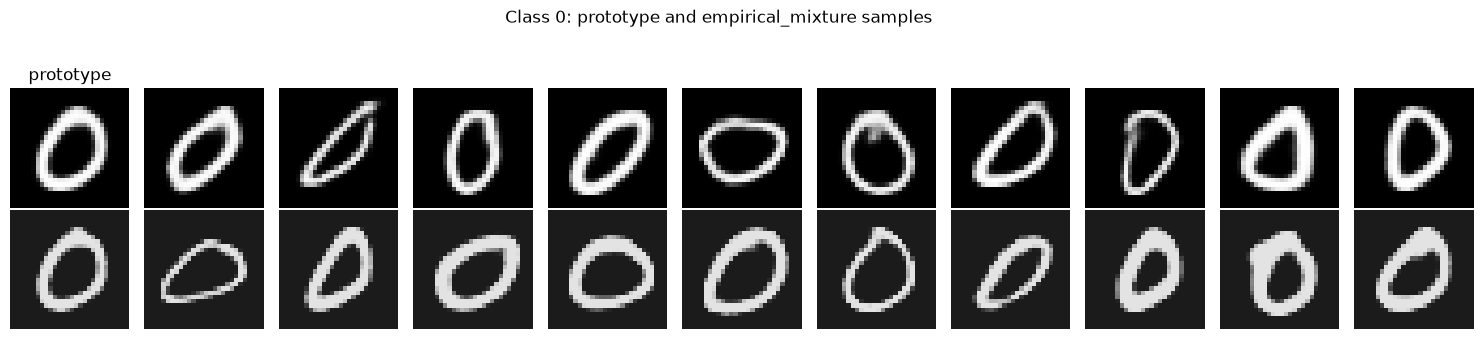

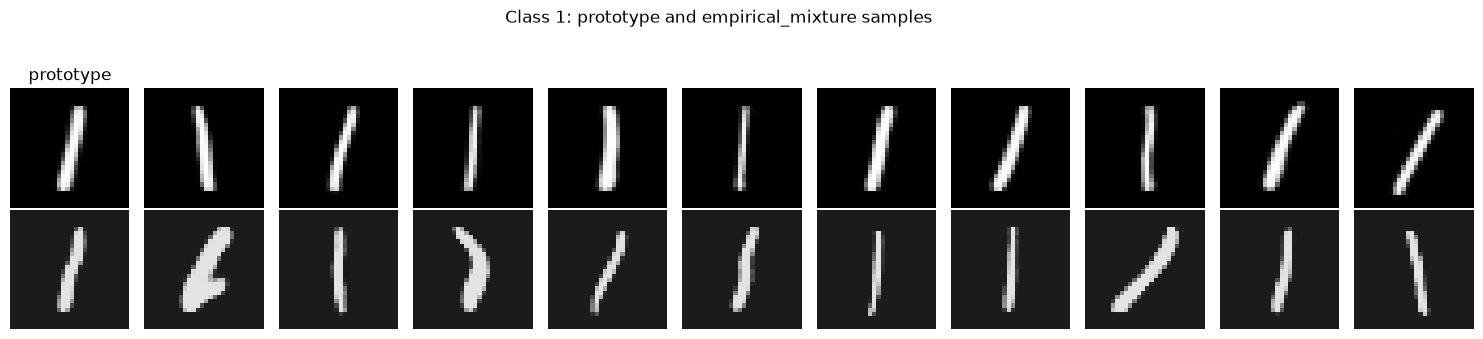

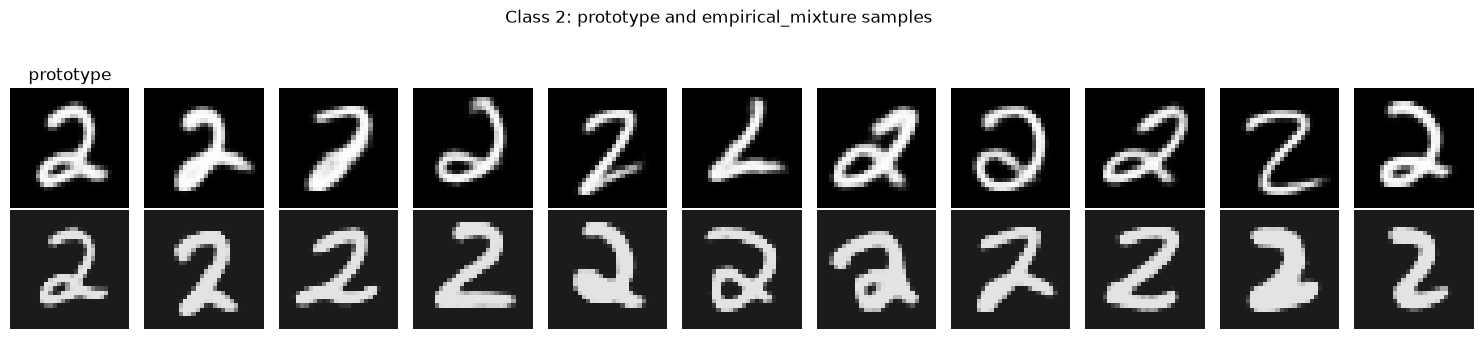

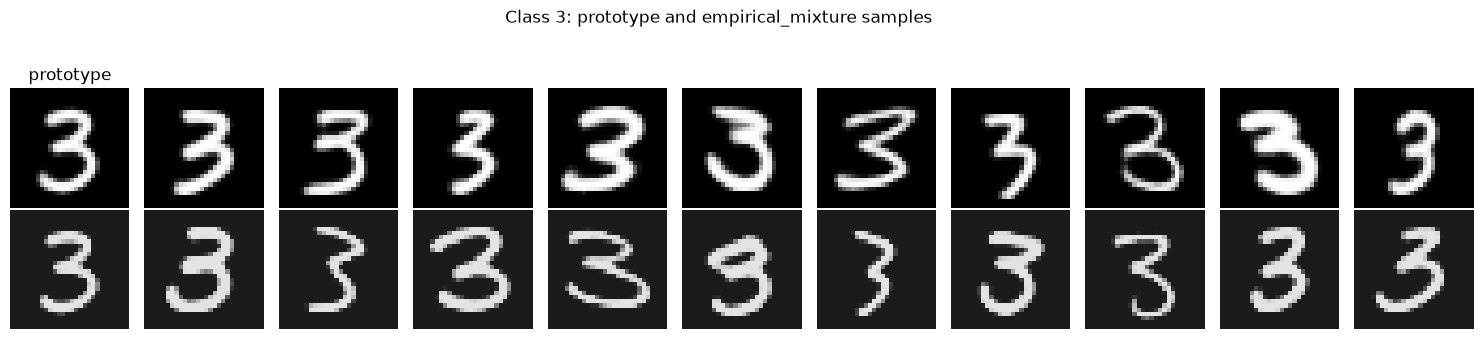

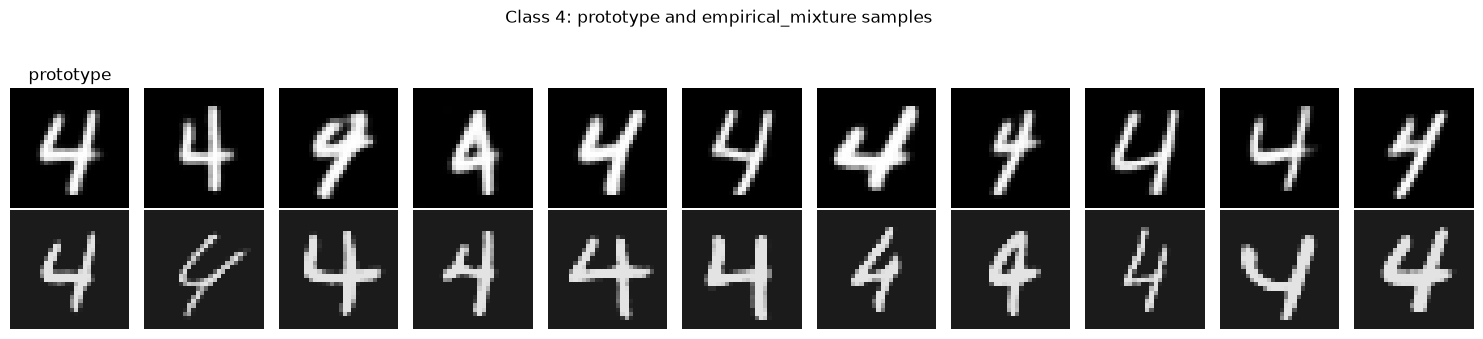

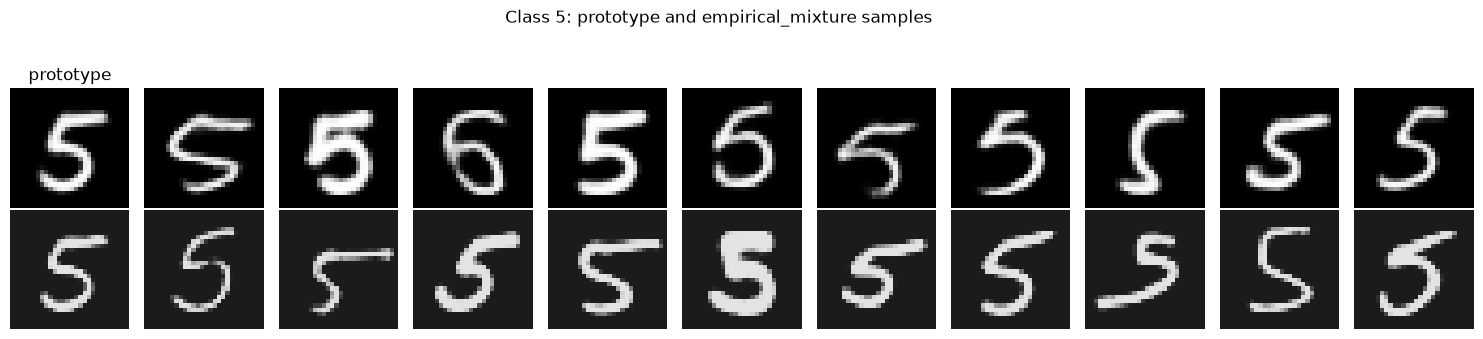

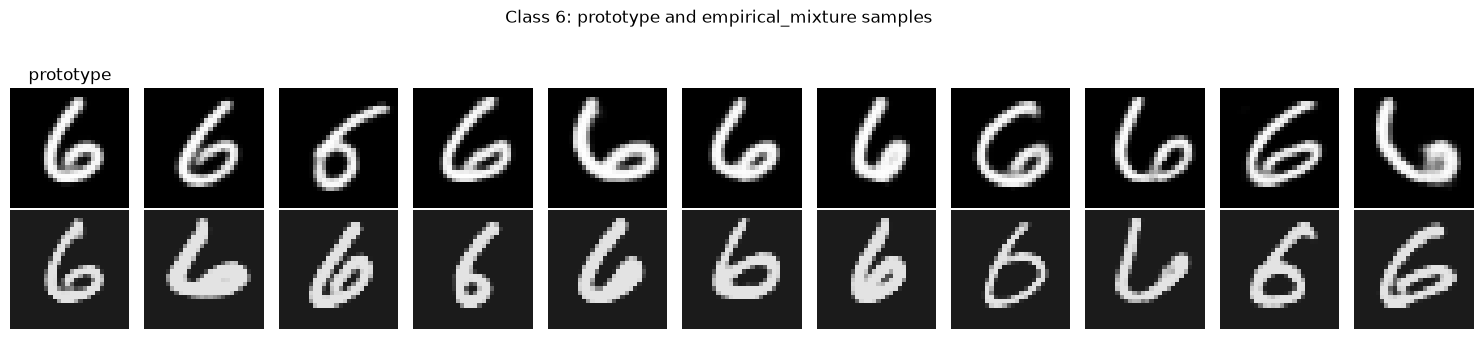

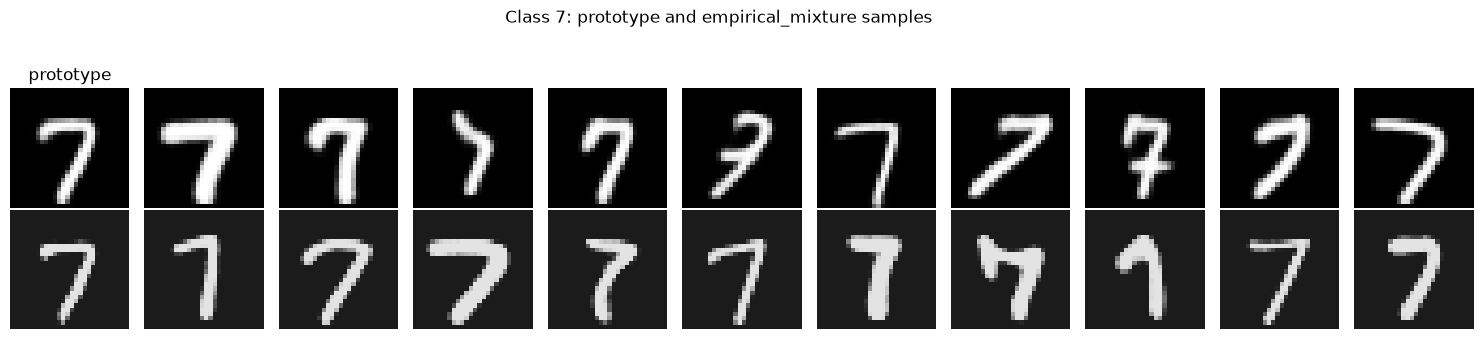

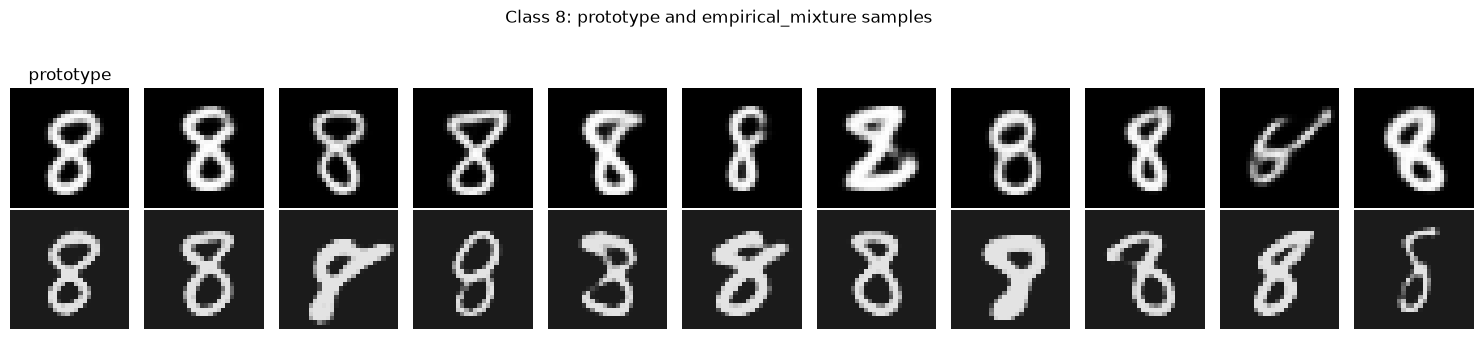

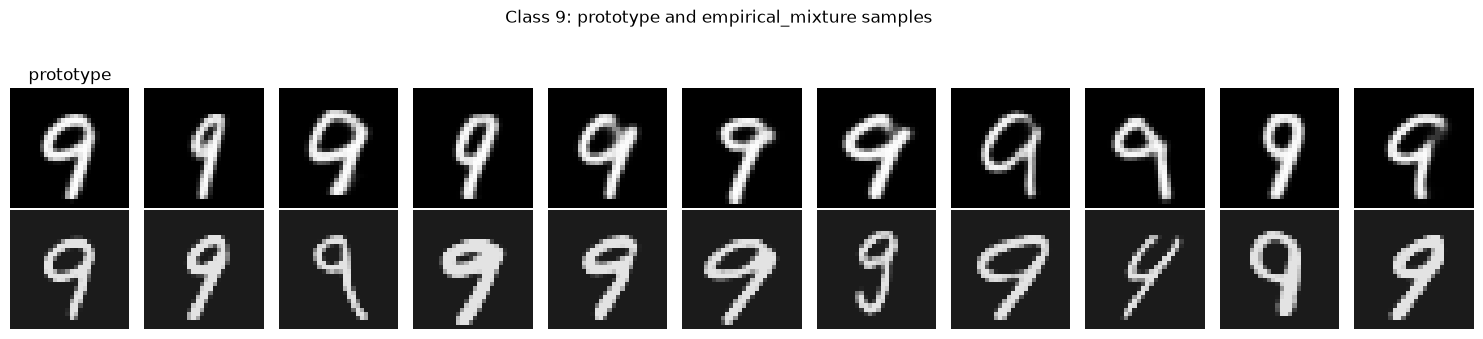

In [19]:
for class_id in class_ids:
    figure, axes = plt.subplots(
        nrows=2,
        ncols=NUM_CLASS_SAMPLES + 1,
        figsize=(1.4 * (NUM_CLASS_SAMPLES + 1), 3.5),
        squeeze=False,
    )

    for row, item in enumerate(models):
        generator = torch.Generator().manual_seed(
            RANDOM_SEED + 1000 * row + class_id
        )
        sampled_latents = sample_class_latents(
            item,
            class_id=class_id,
            n_samples=NUM_CLASS_SAMPLES,
            generator=generator,
            method=CLASS_SAMPLING_METHOD,
        )
        prototype = item["class_statistics"][class_id]["mean"].unsqueeze(0)
        latents = torch.cat([prototype, sampled_latents], dim=0)
        images = decode_expected_images(item["model"], latents)

        for column, image in enumerate(images):
            title = "prototype" if row == 0 and column == 0 else None
            show_image(axes[row, column], image, title=title)
        axes[row, 0].set_ylabel(
            item["name"],
            rotation=0,
            labelpad=45,
            va="center",
        )

    figure.suptitle(
        f"Class {class_id}: prototype and {CLASS_SAMPLING_METHOD} samples"
    )
    plt.tight_layout(rect=(0.03, 0.0, 1.0, 0.93))
    plt.show()
    plt.close(figure)

## Linear interpolation between class prototypes

Every row interpolates between that model's own two class means. Smooth, digit-like transitions indicate that the path remains in a decoder-supported region; broken intermediate images reveal unsupported regions along that particular linear path.

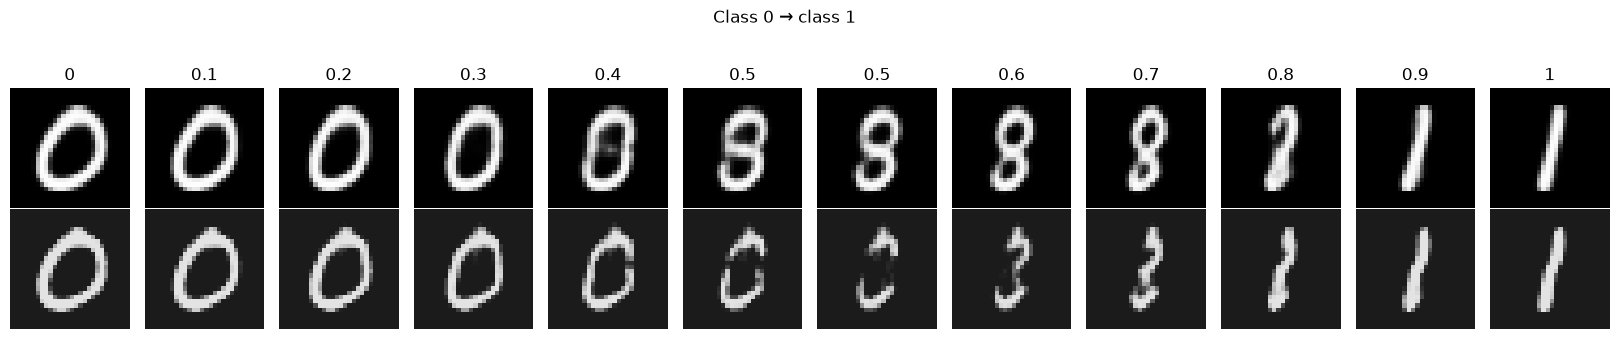

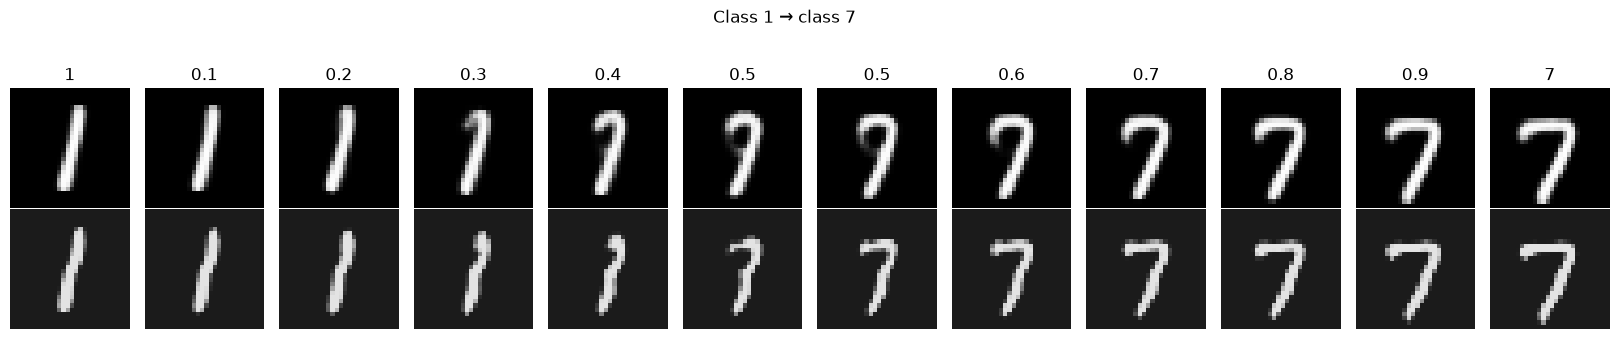

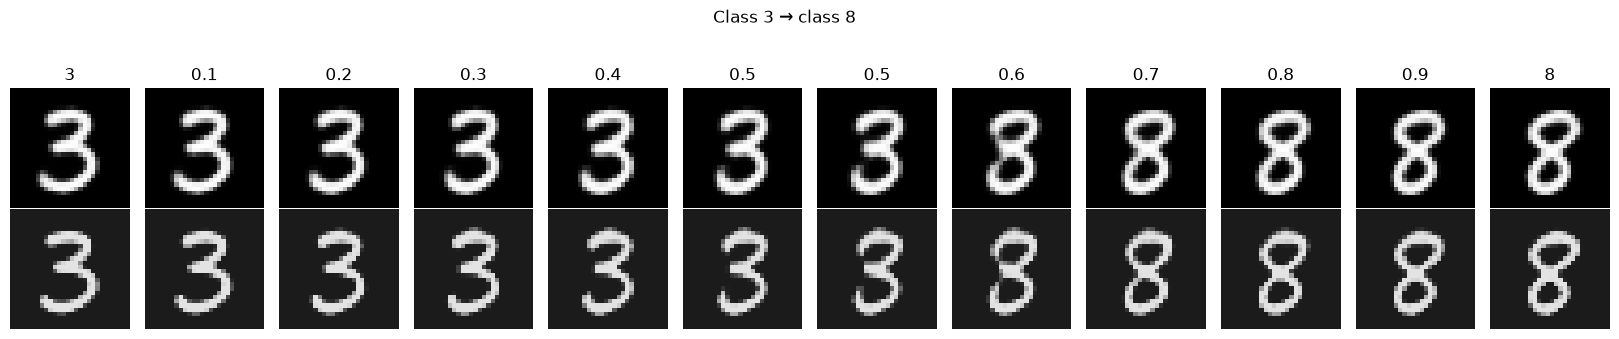

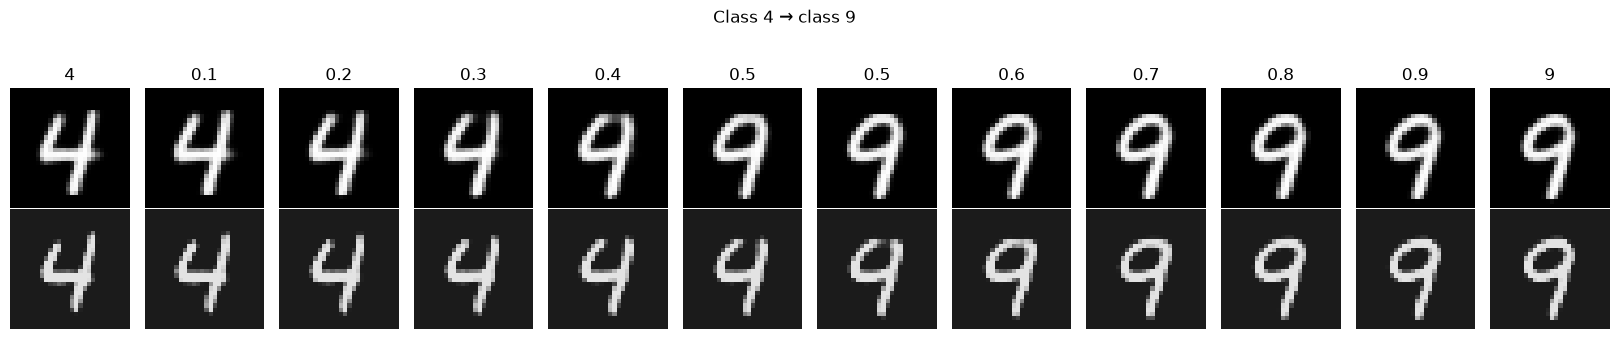

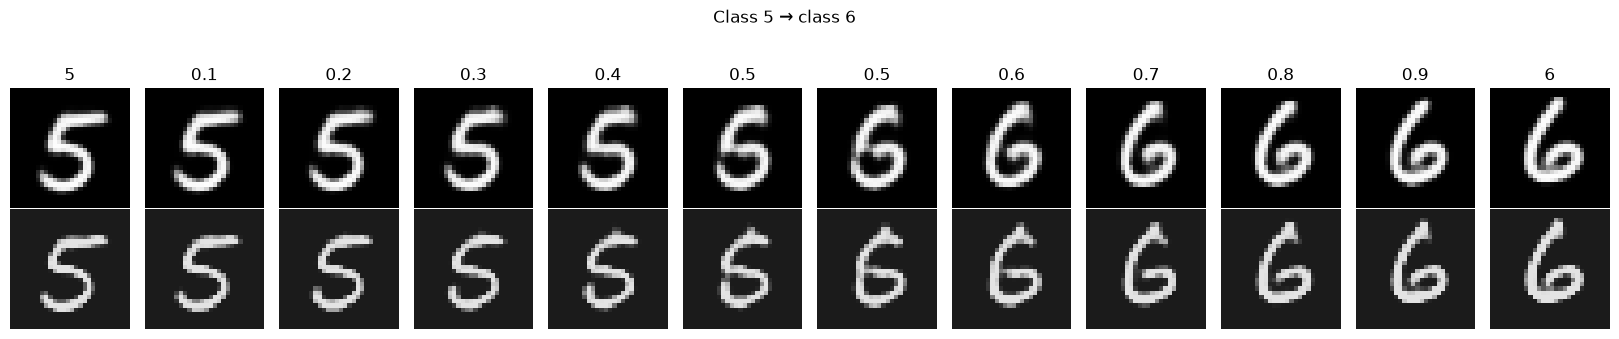

In [20]:
def linear_interpolation(start, end, steps):
    weights = torch.linspace(0.0, 1.0, steps).unsqueeze(1)
    return (1.0 - weights) * start.unsqueeze(0) + weights * end.unsqueeze(0)


for start_class, end_class in INTERPOLATION_PAIRS:
    if start_class not in class_ids or end_class not in class_ids:
        raise ValueError(
            f"Interpolation pair {(start_class, end_class)} is not in {class_ids}."
        )

    figure, axes = plt.subplots(
        nrows=2,
        ncols=INTERPOLATION_STEPS,
        figsize=(1.4 * INTERPOLATION_STEPS, 3.5),
        squeeze=False,
    )

    for row, item in enumerate(models):
        start = item["class_statistics"][start_class]["mean"]
        end = item["class_statistics"][end_class]["mean"]
        path = linear_interpolation(start, end, INTERPOLATION_STEPS)
        images = decode_expected_images(item["model"], path)

        for column, image in enumerate(images):
            if row == 0:
                if column == 0:
                    title = str(start_class)
                elif column == INTERPOLATION_STEPS - 1:
                    title = str(end_class)
                else:
                    title = f"{column / (INTERPOLATION_STEPS - 1):.1f}"
            else:
                title = None
            show_image(axes[row, column], image, title=title)

        axes[row, 0].set_ylabel(
            item["name"],
            rotation=0,
            labelpad=45,
            va="center",
        )

    figure.suptitle(f"Class {start_class} → class {end_class}")
    plt.tight_layout(rect=(0.03, 0.0, 1.0, 0.93))
    plt.show()
    plt.close(figure)

## Interpretation notes

- Prior samples test regions reached by $z \sim \mathcal{N}(0,I)$; class-conditioned samples test regions reached by encoded data.
- Good class samples together with poor prior samples are evidence of a mismatch between the aggregate posterior and the prior, not simply insufficient decoder capacity.
- The empirical class posterior is a mixture of encoder Gaussians. It is generally not exactly Normal.
- Latent axes are not aligned between separately trained models. Compare image quality and path behavior, not coordinate-by-coordinate latent values.